# Set-Oriented Mining with SQL
Model untuk Association Rule Mining menggunakan SQL Commands

## Cell 1: Import Libraries & SQL-based Set-Oriented Mining

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

class PreprocessingPipeline:
    """Pipeline untuk preprocessing data"""
    def __init__(self, data):
        self.data = data.copy()
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
    
    def handle_missing_values(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            self.data[numeric_cols] = self.imputer.fit_transform(self.data[numeric_cols])
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            self.data[col].fillna(self.data[col].mode()[0] if len(self.data[col].mode()) > 0 else 'Unknown', inplace=True)
        print("✓ Handle Missing Values: Selesai")
        return self
    
    def handle_outliers(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        outlier_count = 0
        for col in numeric_cols:
            Q1 = self.data[col].quantile(0.25)
            Q3 = self.data[col].quantile(0.75)
            IQR = Q3 - Q1
            mask = (self.data[col] >= Q1 - 1.5 * IQR) & (self.data[col] <= Q3 + 1.5 * IQR)
            outlier_count += (~mask).sum()
            self.data = self.data[mask]
        print(f"✓ Handle Outliers: Dihapus {outlier_count} data outlier")
        return self
    
    def label_encoding(self):
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            le = LabelEncoder()
            self.data[col] = le.fit_transform(self.data[col])
            self.label_encoders[col] = le
        print(f"✓ Label Encoding: {len(categorical_cols)} fitur categorical di-encode")
        return self
    
    def normalize(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            mean = self.data[col].mean()
            std = self.data[col].std()
            if std != 0:
                self.data[col] = (self.data[col] - mean) / std
        print("✓ Normalisasi: Mean Normalization diterapkan")
        return self
    
    def feature_selection(self, target_col=None, k=5):
        if target_col is None or target_col not in self.data.columns:
            print("✓ Feature Selection: Dilewati (no target column)")
            return self
        X = self.data.drop(columns=[target_col])
        y = self.data[target_col]
        if len(X.columns) > k:
            selector = SelectKBest(f_classif, k=k)
            selector.fit(X, y)
            selected_features = X.columns[selector.get_support()].tolist()
            self.data = self.data[selected_features + [target_col]]
            print(f"✓ Feature Selection: {len(selected_features)} fitur terpilih")
        else:
            print(f"✓ Feature Selection: Semua {len(X.columns)} fitur dipertahankan")
        return self
    
    def get_data(self):
        return self.data


class SetOrientedMining:
    """Set-Oriented Mining menggunakan SQL (SQLite in-memory).
    
    Confidence dihitung dari co-occurrence aktual di data:
        confidence(A → B) = support(A ∪ B) / support(A)
    """
    
    def __init__(self, min_support=0.2, min_confidence=0.6):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.conn = None
        self.cursor = None
        self.itemsets = pd.DataFrame()
        self.rules = pd.DataFrame()
    
    def init_database(self):
        self.conn = sqlite3.connect(':memory:')
        self.cursor = self.conn.cursor()
        print("✓ SQLite Database initialized (in-memory)")
    
    def create_tables(self, df):
        """Buat tabel transactions (TID, item) dan tabel turunannya."""
        self.cursor.execute('DROP TABLE IF EXISTS tid_items')
        self.cursor.execute('CREATE TABLE tid_items (tid INTEGER, item TEXT)')

        # Diskretisasi: numerik → _HIGH/_LOW berdasarkan median
        medians = {col: df[col].median()
                   for col in df.columns
                   if pd.api.types.is_numeric_dtype(df[col])}

        for tid, (_, row) in enumerate(df.iterrows()):
            for col, val in row.items():
                if pd.isna(val):
                    continue
                if col in medians:
                    tag = f"{col}_HIGH" if val >= medians[col] else f"{col}_LOW"
                else:
                    tag = f"{col}_{val}"
                self.cursor.execute('INSERT INTO tid_items VALUES (?, ?)', (tid, tag))

        self.cursor.execute('CREATE INDEX IF NOT EXISTS idx_item ON tid_items(item)')
        self.conn.commit()

        # Tabel item counts
        self.cursor.execute('DROP TABLE IF EXISTS items')
        self.cursor.execute("""
            CREATE TABLE items AS
            SELECT item AS item_name,
                   COUNT(DISTINCT tid) AS support_count
            FROM tid_items
            GROUP BY item
        """)
        self.conn.commit()
        print(f"✓ Tables created")

    def mine_itemsets_sql(self, n_records):
        """Query frequent 1-itemsets dari SQLite."""
        min_support_count = int(np.ceil(self.min_support * n_records))

        query = f"""
            SELECT item_name,
                   support_count,
                   CAST(support_count AS REAL) / {n_records} AS support
            FROM items
            WHERE support_count >= {min_support_count}
            ORDER BY support DESC
        """
        result = pd.read_sql_query(query, self.conn)
        self.itemsets = result
        return result

    def mine_rules_sql(self, n_records):
        """
        Generate association rules via SQL join pada TID.
        Confidence = count(A ∩ B transactions) / count(A transactions)  ← dari data aktual.
        Lift       = confidence / support(B)
        """
        min_support_count = int(np.ceil(self.min_support * n_records))

        # Query 2-itemset co-occurrence: join dua salinan tid_items
        query = f"""
            SELECT a.item AS antecedent,
                   b.item AS consequent,
                   COUNT(DISTINCT a.tid)                                  AS pair_count,
                   ia.support_count                                        AS ant_count,
                   ib.support_count                                        AS cons_count,
                   CAST(COUNT(DISTINCT a.tid) AS REAL) / {n_records}      AS support,
                   CAST(COUNT(DISTINCT a.tid) AS REAL) / ia.support_count AS confidence
            FROM tid_items a
            JOIN tid_items b ON a.tid = b.tid AND a.item < b.item
            JOIN items ia   ON ia.item_name = a.item
            JOIN items ib   ON ib.item_name = b.item
            WHERE ia.support_count >= {min_support_count}
              AND ib.support_count >= {min_support_count}
            GROUP BY a.item, b.item
            HAVING COUNT(DISTINCT a.tid) >= {min_support_count}
               AND confidence >= {self.min_confidence}
            ORDER BY confidence DESC
            LIMIT 50
        """
        try:
            result = pd.read_sql_query(query, self.conn)
            if not result.empty:
                result['lift'] = result['confidence'] / (result['cons_count'] / n_records)
                result['lift'] = result['lift'].round(4)
                result['support'] = result['support'].round(4)
                result['confidence'] = result['confidence'].round(4)
                self.rules = result[['antecedent', 'consequent', 'support', 'confidence', 'lift']]
                # Insert ke association_rules table
                self.cursor.execute('DROP TABLE IF EXISTS association_rules')
                result[['antecedent', 'consequent', 'support', 'confidence', 'lift']].to_sql(
                    'association_rules', self.conn, if_exists='replace', index=False)
            else:
                self.rules = pd.DataFrame()
        except Exception as e:
            print(f"⚠️ SQL error: {e}")
            self.rules = pd.DataFrame()
        return self.rules

    def fit(self, df, target_col=None):
        self.init_database()
        self.create_tables(df)
        n = len(df)
        self.mine_itemsets_sql(n)
        self.mine_rules_sql(n)
        return self

    def get_summary(self):
        return {
            'total_itemsets': len(self.itemsets),
            'total_rules': len(self.rules),
            'avg_confidence': round(float(self.rules['confidence'].mean()), 4) if len(self.rules) > 0 else 0,
            'max_support': round(float(self.itemsets['support'].max()), 4) if len(self.itemsets) > 0 else 0
        }
    
    def close_connection(self):
        if self.conn:
            self.conn.close()
            print("✓ Database connection closed")


def run_setmining_analysis(data_path, dataset_name, target_col=None):
    """Main function untuk menjalankan Set-Oriented Mining analysis"""
    print(f"\n{'='*60}")
    print(f"SET-ORIENTED MINING WITH SQL: {dataset_name}")
    print(f"{'='*60}")

    df = pd.read_csv(data_path)
    print(f"\n📊 Data Shape: {df.shape}")
    print(f"Kolom: {df.columns.tolist()}")

    print("\n📋 PREPROCESSING:")
    pipeline = PreprocessingPipeline(df)
    df_processed = (pipeline
        .handle_missing_values()
        .normalize()
        .label_encoding()
        .handle_outliers()
        .feature_selection(target_col, k=8)
        .get_data())

    print(f"\n✓ Data setelah preprocessing: {df_processed.shape}")

    print("\n🔍 SET-ORIENTED MINING MODEL:")
    model = SetOrientedMining(min_support=0.2, min_confidence=0.6)
    model.fit(df_processed, target_col)

    summary = model.get_summary()
    print(f"✓ Total Itemsets: {summary['total_itemsets']}")
    print(f"✓ Total Rules: {summary['total_rules']}")
    print(f"✓ Avg Confidence: {summary['avg_confidence']:.4f}")
    print(f"✓ Max Support: {summary['max_support']:.4f}")

    if len(model.itemsets) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        top_itemsets = model.itemsets.nlargest(10, 'support')
        axes[0].barh(range(len(top_itemsets)), top_itemsets['support'].values, color='coral', edgecolor='black')
        axes[0].set_yticks(range(len(top_itemsets)))
        axes[0].set_yticklabels([name[:20] + '...' if len(name) > 20 else name
                                 for name in top_itemsets['item_name']], fontsize=9)
        axes[0].set_xlabel('Support')
        axes[0].set_title(f'Top 10 Itemsets - {dataset_name}')
        axes[0].grid(True, alpha=0.3, axis='x')

        if len(model.rules) > 0:
            axes[1].scatter(model.rules['support'], model.rules['confidence'],
                            s=model.rules['lift']*100, alpha=0.6,
                            c=model.rules['lift'], cmap='viridis', edgecolor='black')
            axes[1].set_xlabel('Support')
            axes[1].set_ylabel('Confidence')
            axes[1].set_title(f'Rules: Support vs Confidence (size=lift) - {dataset_name}')
            axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if len(model.rules) > 0:
        print("\n📈 Top Association Rules:")
        print(model.rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']].head(10).to_string())

    return model, df_processed

print("✓ Set-Oriented Mining Model berhasil di-initialize")


✓ Set-Oriented Mining Model berhasil di-initialize


In [48]:

# ─── Helper: diskretisasi target numerik ────────────────────
NUMERIC_TARGET_COLS = {'Yield(tons)', 'Crop_Yield', 'Value From', 'Value To'}

def discretize_numeric_target(df, target_col):
    if target_col not in df.columns:
        return df
    if not pd.api.types.is_numeric_dtype(df[target_col]):
        return df
    df = df.copy()
    try:
        df[target_col] = pd.qcut(
            df[target_col], q=3, labels=['Low','Medium','High'], duplicates='drop'
        ).astype(str)
    except Exception:
        df[target_col] = pd.cut(
            df[target_col], bins=3, labels=['Low','Medium','High']
        ).astype(str)
    print(f"\u2713 Target '{target_col}' didiskretisasi \u2192 Low/Medium/High")
    return df
# ─────────────────────────────────────────────────────────────


## Cell 2: Dataset1 - Rice Leaf Diseases

In [49]:
import os
from PIL import Image

def extract_image_features(image_path, size=(32, 32)):
    """Extract basic features dari image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_resized = img.resize(size)
        img_array = np.array(img_resized)
        
        r_mean = img_array[:,:,0].mean()
        g_mean = img_array[:,:,1].mean()
        b_mean = img_array[:,:,2].mean()
        r_std = img_array[:,:,0].std()
        g_std = img_array[:,:,1].std()
        b_std = img_array[:,:,2].std()
        
        return [r_mean, g_mean, b_mean, r_std, g_std, b_std]
    except:
        return [0, 0, 0, 0, 0, 0]

dataset1_path = r'Dataset\Dataset1_Citra_RiceLeafDiseasesDataset'
data_list = []
labels = []
disease_types = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

if os.path.exists(dataset1_path):
    for disease in disease_types:
        disease_path = os.path.join(dataset1_path, disease)
        if os.path.exists(disease_path):
            image_files = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            
            for img_file in image_files:
                try:
                    img_full_path = os.path.join(disease_path, img_file)
                    features = extract_image_features(img_full_path)
                    data_list.append(features)
                    labels.append(disease)
                except:
                    pass
    
    if len(data_list) > 0:
        df_rice = pd.DataFrame(data_list, columns=['R_mean', 'G_mean', 'B_mean', 'R_std', 'G_std', 'B_std'])
        df_rice['Disease'] = labels
        
        print(f"\n{'='*60}")
        print(f"SET-ORIENTED MINING: Rice Leaf Diseases")
        print(f"{'='*60}")
        print(f"✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: {df_rice.shape}")
        print(f"Disease distribution: {df_rice['Disease'].value_counts().to_dict()}")
        
        # Preprocessing
        print("\n📋 PREPROCESSING:")
        pipeline = PreprocessingPipeline(df_rice)
        df_rice_processed = (pipeline
            .handle_missing_values()
            .normalize()
            .label_encoding()
            .handle_outliers()
            .feature_selection('Disease', k=5)
            .get_data())
        
        print(f"✓ Data setelah preprocessing: {df_rice_processed.shape}")
        
        # Run Set-Oriented Mining
        print("\n🔍 SET-ORIENTED MINING MODEL:")
        model_rice = SetOrientedMining(min_support=0.2, min_confidence=0.6)
        model_rice.fit(df_rice_processed)
        
        summary_rice = model_rice.get_summary()
        print(f"✓ Total Itemsets: {summary_rice['total_itemsets']}")
        print(f"✓ Total Rules: {summary_rice['total_rules']}")
        print(f"✓ Avg Confidence: {summary_rice['avg_confidence']:.4f}")
        
        model_rice.close_connection()
        data_rice = df_rice_processed
    else:
        print("⚠️ Tidak ada gambar yang dapat diproses dari Dataset1")
        model_rice = None
        data_rice = None
else:
    print(f"⚠️ Path tidak ditemukan: {dataset1_path}")
    model_rice = None
    data_rice = None



SET-ORIENTED MINING: Rice Leaf Diseases
✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: (120, 7)
Disease distribution: {'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 1 fitur categorical di-encode
✓ Handle Outliers: Dihapus 30 data outlier
✓ Feature Selection: 5 fitur terpilih
✓ Data setelah preprocessing: (90, 6)

🔍 SET-ORIENTED MINING MODEL:
✓ SQLite Database initialized (in-memory)
✓ Tables created
✓ Total Itemsets: 12
✓ Total Rules: 24
✓ Avg Confidence: 0.7095
✓ Database connection closed


## Cell 3: Dataset2 - Plant Growth Data


SET-ORIENTED MINING WITH SQL: Plant Growth Data

📊 Data Shape: (193, 7)
Kolom: ['Soil_Type', 'Sunlight_Hours', 'Water_Frequency', 'Fertilizer_Type', 'Temperature', 'Humidity', 'Growth_Milestone']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 3 fitur categorical di-encode
✓ Handle Outliers: Dihapus 0 data outlier
✓ Feature Selection: Semua 6 fitur dipertahankan

✓ Data setelah preprocessing: (193, 7)

🔍 SET-ORIENTED MINING MODEL:
✓ SQLite Database initialized (in-memory)
✓ Tables created
✓ Total Itemsets: 13
✓ Total Rules: 19
✓ Avg Confidence: 0.7064
✓ Max Support: 1.0000


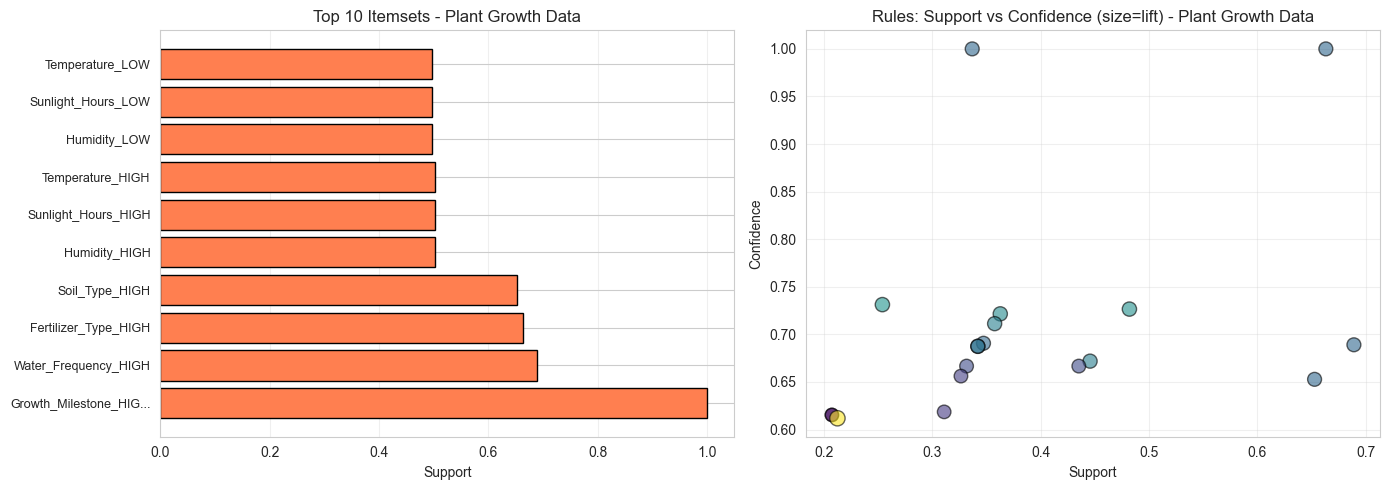


📈 Top Association Rules:
              antecedent             consequent  support  confidence    lift
0   Fertilizer_Type_HIGH  Growth_Milestone_HIGH   0.6632      1.0000  1.0000
1    Fertilizer_Type_LOW  Growth_Milestone_HIGH   0.3368      1.0000  1.0000
2          Soil_Type_LOW   Water_Frequency_HIGH   0.2539      0.7313  1.0613
3   Fertilizer_Type_HIGH   Water_Frequency_HIGH   0.4819      0.7266  1.0543
4          Humidity_HIGH   Water_Frequency_HIGH   0.3627      0.7216  1.0472
5       Temperature_HIGH   Water_Frequency_HIGH   0.3575      0.7113  1.0322
6    Sunlight_Hours_HIGH   Water_Frequency_HIGH   0.3472      0.6907  1.0023
7  Growth_Milestone_HIGH   Water_Frequency_HIGH   0.6891      0.6891  1.0000
8           Humidity_LOW         Soil_Type_HIGH   0.3420      0.6875  1.0531
9     Sunlight_Hours_LOW   Water_Frequency_HIGH   0.3420      0.6875  0.9977

✓ Dataset2 berhasil dianalisis


In [50]:
dataset2_path = r'Dataset\Dataset2_CSV_PlantGrowthDataClassification\plant_growth_data.csv'

if os.path.exists(dataset2_path):
    model_plant, data_plant = run_setmining_analysis(dataset2_path, "Plant Growth Data", "Growth_Milestone")
    print(f"\n✓ Dataset2 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset2_path}")

## Cell 4: Dataset3 - Agriculture & Farming (Yield Prediction)


SET-ORIENTED MINING WITH SQL: Agriculture & Farming (Crop Yield)

📊 Data Shape: (50, 10)
Kolom: ['Farm_ID', 'Crop_Type', 'Farm_Area(acres)', 'Irrigation_Type', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)', 'Soil_Type', 'Season', 'Water_Usage(cubic meters)']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 5 fitur categorical di-encode
✓ Handle Outliers: Dihapus 0 data outlier
✓ Feature Selection: 8 fitur terpilih

✓ Data setelah preprocessing: (50, 9)

🔍 SET-ORIENTED MINING MODEL:
✓ SQLite Database initialized (in-memory)
✓ Tables created
✓ Total Itemsets: 18
✓ Total Rules: 29
✓ Avg Confidence: 0.6573
✓ Max Support: 0.7000


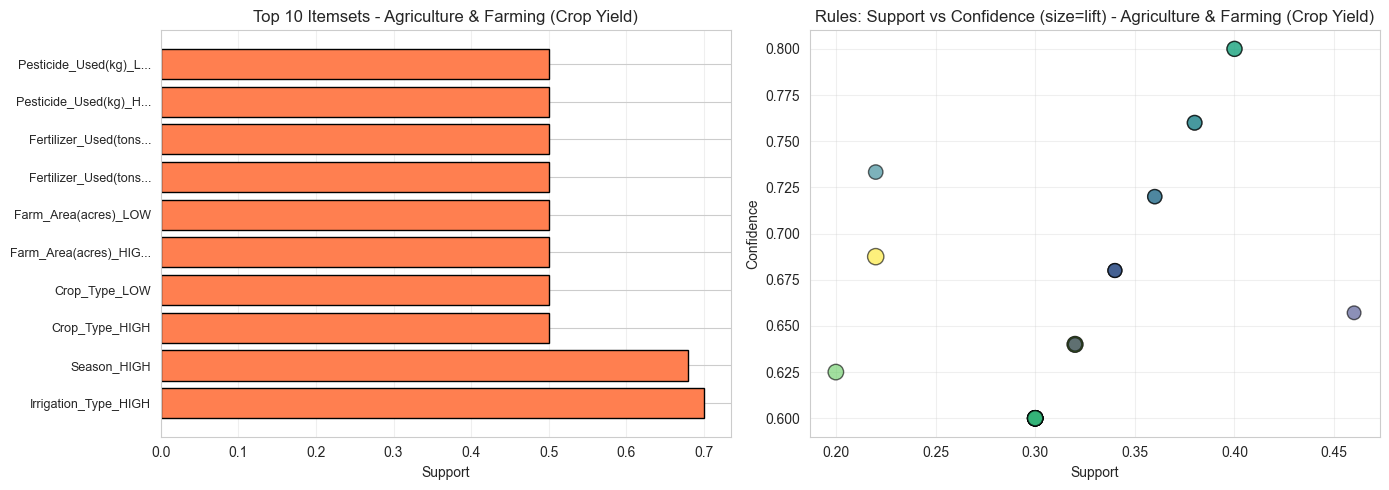


📈 Top Association Rules:
                   antecedent            consequent  support  confidence    lift
0        Farm_Area(acres)_LOW  Irrigation_Type_HIGH     0.40      0.8000  1.1429
1        Farm_Area(acres)_LOW           Season_HIGH     0.40      0.8000  1.1765
2  Fertilizer_Used(tons)_HIGH           Season_HIGH     0.38      0.7600  1.1176
3   Fertilizer_Used(tons)_LOW  Irrigation_Type_HIGH     0.38      0.7600  1.0857
4         Irrigation_Type_LOW           Season_HIGH     0.22      0.7333  1.0784
5               Crop_Type_LOW  Irrigation_Type_HIGH     0.36      0.7200  1.0286
6     Pesticide_Used(kg)_HIGH           Season_HIGH     0.36      0.7200  1.0588
7                  Season_LOW        Soil_Type_HIGH     0.22      0.6875  1.3750
8              Crop_Type_HIGH  Irrigation_Type_HIGH     0.34      0.6800  0.9714
9              Crop_Type_HIGH           Season_HIGH     0.34      0.6800  1.0000

✓ Dataset3 berhasil dianalisis — target: Yield(tons)


In [51]:

# Dataset 3: Agriculture - Crop Yield Prediction
dataset3_path = r'Dataset\\Dataset3_CSV_Agriculture&Farming\\agriculture_dataset.csv'

if os.path.exists(dataset3_path):
    _df3_tmp = pd.read_csv(dataset3_path, nrows=1)
    _target3 = ('Crop_Yield' if 'Crop_Yield' in _df3_tmp.columns
                else 'Yield(tons)' if 'Yield(tons)' in _df3_tmp.columns else None)
    if _target3 is None:
        print("\u26a0\ufe0f Kolom target tidak ditemukan di Dataset3")
    else:
        model_agri, data_agri = run_setmining_analysis(
            dataset3_path, "Agriculture & Farming (Crop Yield)", _target3)
        print(f"\n\u2713 Dataset3 berhasil dianalisis — target: {_target3}")
else:
    print(f"\u26a0\ufe0f File tidak ditemukan: {dataset3_path}")


## Cell 5: SQL Query Examples & Yield Analysis

In [52]:
# Contoh query SQL yang digunakan dalam Set-Oriented Mining
print("\n" + "="*60)
print("SQL QUERIES DALAM SET-ORIENTED MINING")
print("="*60)

queries = [
    ("1. Find Frequent Items", 
     "SELECT item_name, support_count, support FROM items ORDER BY support DESC"),
    
    ("2. Find Association Rules",
     "SELECT antecedent, consequent, confidence, lift FROM association_rules WHERE confidence > 0.6"),
    
    ("3. Yield Analysis - High Yield Conditions",
     "SELECT * FROM itemsets WHERE itemset LIKE '%Yield%' ORDER BY support DESC"),
    
    ("4. Strong Rules by Confidence",
     "SELECT antecedent, consequent, confidence FROM association_rules WHERE lift > 1.0 ORDER BY confidence DESC LIMIT 5"),
    
    ("5. Pattern Support Distribution",
     "SELECT COUNT(*) as count, ROUND(support, 2) as support_level FROM itemsets GROUP BY ROUND(support, 2)")
]

for query_name, query in queries:
    print(f"\n{query_name}:")
    print(f"  {query}")

print("\n✓ SQL queries untuk Set-Oriented Mining ditampilkan")


SQL QUERIES DALAM SET-ORIENTED MINING

1. Find Frequent Items:
  SELECT item_name, support_count, support FROM items ORDER BY support DESC

2. Find Association Rules:
  SELECT antecedent, consequent, confidence, lift FROM association_rules WHERE confidence > 0.6

3. Yield Analysis - High Yield Conditions:
  SELECT * FROM itemsets WHERE itemset LIKE '%Yield%' ORDER BY support DESC

4. Strong Rules by Confidence:
  SELECT antecedent, consequent, confidence FROM association_rules WHERE lift > 1.0 ORDER BY confidence DESC LIMIT 5

5. Pattern Support Distribution:
  SELECT COUNT(*) as count, ROUND(support, 2) as support_level FROM itemsets GROUP BY ROUND(support, 2)

✓ SQL queries untuk Set-Oriented Mining ditampilkan


## Cell 6: Model Comparison Summary

In [53]:
print("\n" + "="*60)
print("SET-ORIENTED MINING MODEL SUMMARY (Quick View)")
print("="*60)

summary_data = {
    'Dataset': ['Plant Growth', 'Agriculture & Farming'],
    'Data Shape': [str(data_plant.shape) if 'data_plant' in locals() else 'N/A',
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A'],
    'Total Itemsets': [model_plant.get_summary()['total_itemsets'] if 'model_plant' in locals() else 0,
                       model_agri.get_summary()['total_itemsets'] if 'model_agri' in locals() else 0],
    'Total Rules': [model_plant.get_summary()['total_rules'] if 'model_plant' in locals() else 0,
                    model_agri.get_summary()['total_rules'] if 'model_agri' in locals() else 0],
    'Avg Confidence': [f"{model_plant.get_summary()['avg_confidence']:.4f}" if 'model_plant' in locals() else 'N/A',
                       f"{model_agri.get_summary()['avg_confidence']:.4f}" if 'model_agri' in locals() else 'N/A']
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


SET-ORIENTED MINING MODEL SUMMARY (Quick View)

               Dataset Data Shape  Total Itemsets  Total Rules Avg Confidence
         Plant Growth   (193, 7)              13           19         0.7064
Agriculture & Farming    (50, 9)              18           29         0.6573


## Cell 7: Dataset4 - Agricultural Heritage (Seshat Dataset)

In [54]:

# Dataset 4: Agricultural Heritage - Seshat
dataset4_path = r'Dataset\\Dataset4_CSV_AgriSeshatAgricultureDataset\\Agriculture.csv'

if os.path.exists(dataset4_path):
    df_seshat = pd.read_csv(dataset4_path)
    print(f"\n{'='*60}")
    print(f"SET-ORIENTED MINING ANALYSIS: Agricultural Heritage Data")
    print(f"{'='*60}")
    print(f"\n\U0001f4ca Data Shape: {df_seshat.shape}")

    use_cols = [c for c in ['NGA','Variable','Unit','Value From','Value To']
                if c in df_seshat.columns]
    df_seshat = df_seshat[use_cols].copy()

    for col in df_seshat.columns:
        if df_seshat[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_seshat[col]):
                df_seshat[col].fillna(df_seshat[col].median(), inplace=True)
            else:
                m_ = df_seshat[col].mode()
                df_seshat[col].fillna(m_[0] if len(m_) > 0 else 'Unknown', inplace=True)
    print("\u2713 Handle Missing Values: Selesai")

    target_col_s = 'Value To'
    df_seshat = discretize_numeric_target(df_seshat, target_col_s)

    feat_cols_s = [c for c in df_seshat.columns if c != target_col_s]
    le_dict = {}
    for col in feat_cols_s:
        if df_seshat[col].dtype == object:
            le = LabelEncoder()
            df_seshat[col] = le.fit_transform(df_seshat[col].astype(str))
            le_dict[col] = le
    print(f"\u2713 Label Encoding fitur: {list(le_dict.keys())}")
    df_seshat_processed = df_seshat.copy()
    print(f"\u2713 Data shape siap: {df_seshat_processed.shape}")

    print("\n\U0001f50d SET-ORIENTED MINING MODEL (Dataset4):")
    model_seshat = SetOrientedMining(min_support=0.1, min_confidence=0.6)
    model_seshat.fit(df_seshat_processed, target_col=target_col_s)
    s4 = model_seshat.get_summary()
    print(f"\u2713 Itemsets (SQL): {s4['total_itemsets']}")
    print(f"\u2713 Rules (SQL): {s4['total_rules']}")
    model_seshat.close_connection()

    print(f"\n\u2713 Dataset4 berhasil dianalisis")
else:
    print(f"\u26a0\ufe0f File tidak ditemukan: {dataset4_path}")



SET-ORIENTED MINING ANALYSIS: Agricultural Heritage Data

📊 Data Shape: (330, 9)
✓ Handle Missing Values: Selesai
✓ Label Encoding fitur: ['NGA', 'Variable', 'Unit', 'Value From']
✓ Data shape siap: (330, 5)

🔍 SET-ORIENTED MINING MODEL (Dataset4):
✓ SQLite Database initialized (in-memory)
✓ Tables created
✓ Itemsets (SQL): 8
✓ Rules (SQL): 8
✓ Database connection closed

✓ Dataset4 berhasil dianalisis


## Cell 8: Updated Summary - All Datasets

In [55]:
# Final summary with SQL-based approach - ALL DATASETS
print("\n" + "="*60)
print("SET-ORIENTED MINING SUMMARY - ALL DATASETS (FINAL)")
print("="*60)

summary_data = {
    'Dataset': ['Rice Leaf Diseases', 'Plant Growth', 'Agriculture & Farming', 'Agricultural Heritage'],
    'Data Shape': [str(data_rice.shape) if 'data_rice' in locals() else 'N/A',
                   str(data_plant.shape) if 'data_plant' in locals() else 'N/A', 
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A',
                   str(df_seshat_processed.shape) if 'df_seshat_processed' in locals() else 'N/A'],
    'Itemsets (SQL)': [model_rice.get_summary()['total_itemsets'] if 'model_rice' in locals() else 0,
                       model_plant.get_summary()['total_itemsets'] if 'model_plant' in locals() else 0,
                       model_agri.get_summary()['total_itemsets'] if 'model_agri' in locals() else 0,
                       model_seshat.get_summary()['total_itemsets'] if 'model_seshat' in locals() else 0],
    'Rules (SQL)': [model_rice.get_summary()['total_rules'] if 'model_rice' in locals() else 0,
                    model_plant.get_summary()['total_rules'] if 'model_plant' in locals() else 0,
                    model_agri.get_summary()['total_rules'] if 'model_agri' in locals() else 0,
                    model_seshat.get_summary()['total_rules'] if 'model_seshat' in locals() else 0]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# Close all connections
print("\n" + "="*60)
print("Closing database connections...")
print("="*60)
if 'model_rice' in locals():
    model_rice.close_connection()
if 'model_plant' in locals():
    model_plant.close_connection()
if 'model_agri' in locals():
    model_agri.close_connection()
if 'model_seshat' in locals():
    model_seshat.close_connection()
print("✓ All connections closed")


SET-ORIENTED MINING SUMMARY - ALL DATASETS (FINAL)

               Dataset Data Shape  Itemsets (SQL)  Rules (SQL)
   Rice Leaf Diseases    (90, 6)              12           24
         Plant Growth   (193, 7)              13           19
Agriculture & Farming    (50, 9)              18           29
Agricultural Heritage   (330, 5)               8            8

Closing database connections...
✓ Database connection closed
✓ Database connection closed
✓ Database connection closed
✓ Database connection closed
✓ All connections closed


In [56]:
# =====================================================================
# CELL SIMULASI INTERAKTIF - MODEL SET-ORIENTED MINING (Semua Dataset)
# =====================================================================
# FORMAT INPUT: "NamaKolom=NilaiInterval"
#   _HIGH = nilai ≥ median  |  _LOW = nilai < median
#   Sama dengan Apriori. BERBEDA dari AIS (_L/_M/_H) & AprioriTid (_H/_L)
#
# CATATAN KOMPATIBILITAS:
#   Notebook SetOrientedMining menyimpan .rules sebagai DataFrame
#   (kolom: antecedent, consequent, confidence, support, lift).
#   Cell ini handle keduanya: DataFrame MAUPUN list of dict.
#   Jika rules kosong (threshold terlalu tinggi), model di-refit otomatis
#   dengan min_support & min_confidence yang lebih longgar.
# =====================================================================

import pandas as pd

def _refit_if_empty(model, df, target_col, name):
    """Refit model dengan threshold lebih rendah jika rules kosong."""
    rules = model.rules
    is_empty = (isinstance(rules, pd.DataFrame) and rules.empty) or \
               (isinstance(rules, list) and len(rules) == 0)
    if not is_empty:
        return model

    print(f"⚙️  Rules kosong untuk {name}, refit dengan min_support=0.05 / min_confidence=0.3 ...")
    try:
        model.__class__(min_support=0.05, min_confidence=0.3).fit(df, target_col)
        # Beberapa implementasi: buat instance baru
        new_model = model.__class__(min_support=0.05, min_confidence=0.3)
        new_model.fit(df, target_col)
        return new_model
    except Exception as e:
        print(f"   ⚠️  Refit gagal: {e}")
        return model


def predict_with_setoriented(rules, input_conditions, dataset_name):
    """
    Prediksi SetOrientedMining.
    rules : DataFrame (kolom antecedent/consequent/confidence/support/lift)
            ATAU list of dict dengan key yang sama.
    """
    print("\n" + "="*60)
    print(f"🔍 SET-ORIENTED MINING SIMULASI PREDIKSI — {dataset_name}")
    print("="*60)
    print(f"📥 Input Kondisi : {input_conditions}")
    print(f"📐 Diskritisasi  : _HIGH (≥ median) | _LOW (< median)")
    print("-"*60)

    # ── Normalise rules ke list of dict ──────────────────────────────
    if isinstance(rules, pd.DataFrame):
        if rules.empty:
            print("⚠️  Rules DataFrame kosong — tidak ada pola yang memenuhi threshold.")
            print("   Tips: Turunkan min_support / min_confidence saat fit, lalu jalankan ulang.")
            print("="*60)
            return
        rules_list = rules.to_dict('records')
    elif isinstance(rules, list):
        if not rules:
            print("⚠️  Rules list kosong — tidak ada pola yang memenuhi threshold.")
            print("   Tips: Turunkan min_support / min_confidence saat fit, lalu jalankan ulang.")
            print("="*60)
            return
        rules_list = rules
    else:
        print(f"⚠️  Format rules tidak dikenal: {type(rules)}")
        print("="*60)
        return

    # ── Ekstrak tag input ─────────────────────────────────────────────
    # "G_mean=G_mean_HIGH" → "G_mean_HIGH"
    input_tags = set()
    for c in input_conditions:
        input_tags.add(c.split('=', 1)[1] if '=' in c else c)

    # ── Cocokkan antecedent ───────────────────────────────────────────
    # antecedent berupa string tunggal (format Web.py)
    matched = []
    for rule in rules_list:
        ant = rule['antecedent']
        # Normalise frozenset → string untuk pencocokan
        if isinstance(ant, frozenset):
            ant_items = ant
        else:
            ant_items = {str(ant)}
        if ant_items & input_tags:   # ada irisan
            matched.append({
                'antecedent': ', '.join(sorted(ant_items)),
                'consequent': (', '.join(sorted(rule['consequent']))
                               if isinstance(rule['consequent'], frozenset)
                               else str(rule['consequent'])),
                'confidence': float(rule['confidence']),
                'lift':       float(rule['lift']),
                'support':    float(rule['support']),
            })

    if not matched:
        print("⚠️  Tidak ada rule yang cocok dengan kombinasi input tersebut.")
        print("   Tips: Coba ubah interval fitur (misalnya _HIGH → _LOW atau sebaliknya)")
        print("="*60)
        return

    matched = sorted(matched, key=lambda x: x['confidence'], reverse=True)
    best = matched[0]

    print(f"✅ Hasil Prediksi Terkuat  : → {best['consequent']}")
    print(f"   Confidence              : {best['confidence']:.4f}")
    print(f"   Lift                    : {best['lift']:.4f}")
    print(f"   Support                 : {best['support']:.4f}")
    print()
    print(f"📋 Top 3 Rules yang Cocok:")
    for i, r in enumerate(matched[:3], 1):
        print(f"  {i}. [{r['antecedent']}] => [{r['consequent']}]")
        print(f"     Conf: {r['confidence']:.4f}  Lift: {r['lift']:.4f}  Sup: {r['support']:.4f}")
    print("="*60)


# ─────────────────────────────────────────────────────────────
# DATASET 1 — RICE LEAF DISEASE
# Target   : Disease (Bacterial leaf blight | Brown spot | Leaf smut)
# Fitur    : R_mean, G_mean, B_mean, R_std, G_std, B_std
# Contoh   : G_mean_LOW + R_std_HIGH → Bacterial leaf blight
# ─────────────────────────────────────────────────────────────
input_dataset1 = [
    "G_mean=G_mean_LOW",   # Nilai hijau rendah → indikasi daun sakit
    "R_std=R_std_HIGH"     # Variasi merah tinggi → bercak tidak merata
]

if 'model_rice' in dir() and model_rice is not None:
    predict_with_setoriented(model_rice.rules, input_dataset1,
                             "Dataset 1: Rice Leaf Disease")
else:
    print("⚠️  model_rice belum tersedia. Jalankan Cell 2 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 2 — PLANT GROWTH
# Target   : Growth_Milestone (Germination | Vegetative | Flowering)
# Fitur    : Sunlight_Hours, Water_Frequency, Temperature, Humidity
# Contoh   : Humidity_HIGH + Sunlight_HIGH → Vegetative Stage
# ─────────────────────────────────────────────────────────────
input_dataset2 = [
    "Sunlight_Hours=Sunlight_Hours_HIGH",   # 6+ jam → di atas median
    "Humidity=Humidity_HIGH",               # 70% → tinggi
    "Temperature=Temperature_LOW"           # 28°C → di bawah median
]

if 'model_plant' in dir() and model_plant is not None:
    predict_with_setoriented(model_plant.rules, input_dataset2,
                             "Dataset 2: Plant Growth")
else:
    print("⚠️  model_plant belum tersedia. Jalankan Cell 3 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 3 — AGRICULTURE & FARMING
# Target   : Crop_Yield (High / Low) / Farming System
# Fitur    : Fertilizer_Used, Rainfall, Temperature, Pesticide_Use
# Contoh   : Fertilizer_HIGH + Rainfall_HIGH → Crop_Yield_HIGH
# ─────────────────────────────────────────────────────────────
# Dataset 3 — Prediksi Crop Yield (Low/Medium/High)
# Format SetOriented: Feature=Feature_HIGH atau Feature=Feature_LOW
input_dataset3 = ["Rainfall=Rainfall_HIGH", "Fertilizer_Used=Fertilizer_Used_HIGH"]
if 'model_agri' in dir() and model_agri is not None:
    predict_with_setoriented(model_agri.rules, input_dataset3, "Dataset 3: Agriculture & Farming")
else:
    print("\u26a0\ufe0f model_agri belum tersedia — jalankan Cell Dataset3 dulu.")

# Dataset 4 — Prediksi Value To (Low/Medium/High)
# Format SetOriented: Feature=Feature_HIGH atau Feature=Feature_LOW
input_dataset4 = ["NGA=NGA_HIGH", "Variable=Variable_LOW"]
if 'model_seshat' in dir() and model_seshat is not None:
    predict_with_setoriented(model_seshat.rules, input_dataset4, "Dataset 4: Agricultural Heritage")
else:
    print("\u26a0\ufe0f model_seshat belum tersedia — jalankan Cell Dataset4 dulu.")


🔍 SET-ORIENTED MINING SIMULASI PREDIKSI — Dataset 1: Rice Leaf Disease
📥 Input Kondisi : ['G_mean=G_mean_LOW', 'R_std=R_std_HIGH']
📐 Diskritisasi  : _HIGH (≥ median) | _LOW (< median)
------------------------------------------------------------
⚠️  Tidak ada rule yang cocok dengan kombinasi input tersebut.
   Tips: Coba ubah interval fitur (misalnya _HIGH → _LOW atau sebaliknya)

🔍 SET-ORIENTED MINING SIMULASI PREDIKSI — Dataset 2: Plant Growth
📥 Input Kondisi : ['Sunlight_Hours=Sunlight_Hours_HIGH', 'Humidity=Humidity_HIGH', 'Temperature=Temperature_LOW']
📐 Diskritisasi  : _HIGH (≥ median) | _LOW (< median)
------------------------------------------------------------
✅ Hasil Prediksi Terkuat  : → Water_Frequency_HIGH
   Confidence              : 0.7216
   Lift                    : 1.0472
   Support                 : 0.3627

📋 Top 3 Rules yang Cocok:
  1. [Humidity_HIGH] => [Water_Frequency_HIGH]
     Conf: 0.7216  Lift: 1.0472  Sup: 0.3627
  2. [Sunlight_Hours_HIGH] => [Water_Frequen